In [1]:
#Impot libraries
import pathlib
import os
import datetime

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import torch
from torch.utils.tensorboard.writer import SummaryWriter
import trimesh
from pytorch3d.loss import chamfer_distance

import utils, dataset, train, visualization
from encoder import *
from decoder import *

%load_ext autoreload
%autoreload 2

/home/nikola/miniconda3/envs/adlr/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Model name
current_time = datetime.datetime.now().strftime("%b%d_%H-%M")
denoiser_name = "3_Objects_50epochs_16batch_KL0.001_hidden_dec128_time_emb"
experiment_name = f"{current_time}_{denoiser_name}"


config = {
    'experiment_name': experiment_name,
    'device': 'cuda:0',
    'batch_size': 16,
    'resume_ckpt': None,
    'learning_rate': 0.0004,
    'step_size': 10, # scheduler step, one step is one batch
    'gamma': 1,
    'max_epochs': 100,
    'timesteps': 1000,
    'print_every_n': 15, # every n batches
    # 'validate_every_n': 10,
    # 'print_EMD_every_n': 1
}

model_config = {
    'last_epoch': 0,
}

In [3]:
# declare device
if torch.cuda.is_available() and config['device'].startswith('cuda'):
    device = torch.device(config['device'])
    print('Using device:', config['device'])
else:
    device = torch.device('cpu')
    print('Using CPU')

# create dataloaders
trainset = dataset.Dataset('overfit', config['timesteps'])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=config['batch_size'], shuffle=True, num_workers=0, pin_memory=False)
# valset = dataset.Dataset('val', config['timesteps'])
# valloader = torch.utils.data.DataLoader(valset, batch_size=config['batch_size'], shuffle=False, num_workers=0)

encoder = Encoder(number_points=2048, in_channels=3, hidden_channels=64, latent_dim=32, clamp=False)
decoder = Decoder(number_points=2048, point_dim=3, hidden_dim=128, latent_dim=32, timesteps=1000, beta_start=1e-4, beta_end=0.02)

# move model to specified device
encoder.to(device)
decoder.to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=config['learning_rate'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, config['step_size'], config['gamma'])
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.0006, steps_per_epoch=len(trainloader), epochs=config['max_epochs'], anneal_strategy='cos', three_phase=True)



# load model if resuming from checkpoint
# experiment_name = "May31_17-04_10_Objects_200epochs_32batch"
# utils.reload_model(encoder, decoder, optimizer, None, experiment_name, 'epoch136', device)


total_enc, trainable_enc = utils.count_parameters(encoder)
total_dec, trainable_dec = utils.count_parameters(decoder)
print(f"Encoder Total: {total_enc:,} | Trainable: {trainable_enc:,} | Model size: {utils.model_memory_size(encoder):.3f} MB")
print(f"Decoder Total: {total_dec:,} | Trainable: {trainable_dec:,} | Model size: {utils.model_memory_size(decoder):.3f} MB")

Using device: cuda:0
Encoder Total: 129,216 | Trainable: 129,216 | Model size: 0.493 MB
Decoder Total: 495,238 | Trainable: 495,238 | Model size: 1.908 MB


In [38]:
torch.cuda.empty_cache()

In [39]:
# start training
torch.cuda.empty_cache()
#tensorboard --logdir=diffusion_autoencoder/logs
# config['max_epochs'] = 200
# Create tensorboard writer    
log_path = pathlib.Path(f"logs/{datetime.datetime.now().strftime('%b%d')}/{config['experiment_name']}")
writer = SummaryWriter(log_path)

with open("debug.txt", "w", encoding="utf-8") as debug_file:
    train.train(encoder, decoder, trainloader, None, device, optimizer, scheduler, config, model_config, writer, None, debug_file)

writer.close()


[00/014] train_loss: 1.193
[00/029] train_loss: 1.131
[00/044] train_loss: 1.086
[00/059] train_loss: 1.027
Best Model:   1.1001855163347154
[01/011] train_loss: 0.716
[01/026] train_loss: 0.321
[01/041] train_loss: 0.251
[01/056] train_loss: 0.216
Best Model:   0.3328104974140251
[02/008] train_loss: 0.172
[02/023] train_loss: 0.194
[02/038] train_loss: 0.184
[02/053] train_loss: 0.181
Best Model:   0.1861275430946123
[03/005] train_loss: 0.200
[03/020] train_loss: 0.179
[03/035] train_loss: 0.171
[03/050] train_loss: 0.176
Best Model:   0.17345569613907072
[04/002] train_loss: 0.161
[04/017] train_loss: 0.178
[04/032] train_loss: 0.148
[04/047] train_loss: 0.162
[04/062] train_loss: 0.139
Best Model:   0.1561900061510858
[05/014] train_loss: 0.170
[05/029] train_loss: 0.163
[05/044] train_loss: 0.171
[05/059] train_loss: 0.179
[06/011] train_loss: 0.155
[06/026] train_loss: 0.144
[06/041] train_loss: 0.167
[06/056] train_loss: 0.162
[07/008] train_loss: 0.168
[07/023] train_loss: 0.1

In [4]:
#Load a model:
experiment_name = "Jun04_02-43_3_Objects_50epochs_16batch_KL0.001_hidden_dec128_time_emb"
utils.reload_model(encoder, decoder, None, None, experiment_name, 'best', device)

({'experiment_name': 'Jun04_02-43_3_Objects_50epochs_16batch_KL0.001_hidden_dec128_time_emb',
  'device': 'cuda:0',
  'batch_size': 16,
  'resume_ckpt': None,
  'learning_rate': 0.0004,
  'step_size': 10,
  'gamma': 1,
  'max_epochs': 100,
  'timesteps': 1000,
  'print_every_n': 15},
 {'last_epoch': 0})

In [6]:
generateDDIM = 1
generateDDPM = 0
number_of_points = 2048
DDIM_steps = 50
number_of_DDIM_iterations = 2
save = False

if generateDDIM:
    for object_index in range(trainset.real_length):
        for i in range(number_of_DDIM_iterations):
            mean, log_variance = encoder(trainset[object_index].unsqueeze(0))
            code = encoder.sample_latent_z(mean, log_variance)

            generated_pc_ddim = sample_ddim(decoder, code, n_points=number_of_points, steps=DDIM_steps)
            generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
            
            dist, _ = chamfer_distance(trainset[object_index].unsqueeze(0), generated_pc_ddim)
            print(f"Chamfer distance, Object{object_index}: {dist}")
            utils.visualize_comparison(trainset[object_index], generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")
            
            if save:
                path = pathlib.Path(f"output/{experiment_name}")
                path.mkdir(parents=True, exist_ok=True)
                generated_pcd_ddim.export(path / f"ddim{DDIM_steps}_{number_of_points}_{i}.obj")

if generateDDPM:
        object_index = 0
        mean, log_variance = encoder(trainset[object_index].unsqueeze(0))
        code = encoder.sample_latent_z(mean, log_variance)
        generated_pc_ddim = sample_ddpm(decoder, code, n_points=number_of_points)
        generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
        utils.visualize_comparison(trainset[object_index], generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")

Chamfer distance, Object0: 0.022286362946033478
Chamfer distance, Object0: 0.021722745150327682
Chamfer distance, Object1: 0.014525685459375381
Chamfer distance, Object1: 0.014290478080511093
Chamfer distance, Object2: 0.011251157149672508
Chamfer distance, Object2: 0.009016422554850578


Object 0: -0.5046169757843018
Object 1: -0.41752195358276367
Object 2: -0.5094771385192871

Running t-SNE with perplexity=2 for 3 samples.


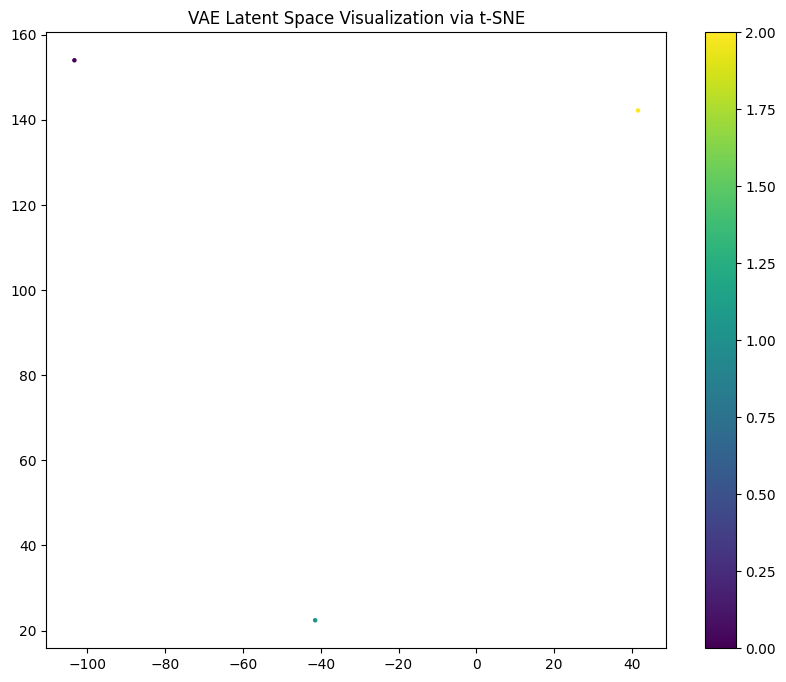

In [16]:
#VAE latent space visualization
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Extract latent representations
encoder.eval()
all_latents = []
all_labels = []

with torch.no_grad():
    for index in range(trainset.real_length):
        data = trainset[index]
        data = data.to(device)
        mu, _ = encoder(data.unsqueeze(0)) 
        mu_list = mu.squeeze().tolist()
        formatted_dims = [f"{val:.3f}" for val in mu_list]
        # mu_list = [float(x) for x in formatted_dims]
        print(f"Object {index}: {mu.mean()}")
        all_latents.append(mu.cpu().numpy())
        all_labels.append(index)

latents = np.concatenate(all_latents, axis=0)
labels = np.array(all_labels)

# 2. Run t-SNE
# 'perplexity' controls the balance between local and global structure (try 30-50)
perplexity = min(30, trainset.real_length - 1)
print(f"\nRunning t-SNE with perplexity={perplexity} for {trainset.real_length} samples.")
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_jobs=-1)
latents_2d = tsne.fit_transform(latents)

# 3. Visualize
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='viridis', s=5)
plt.colorbar(scatter)
plt.title("VAE Latent Space Visualization via t-SNE")
plt.show()

In [9]:
#Decoder interpolation

mean, log_variance = encoder(trainset[0].unsqueeze(0))
print(mean.size())
visualization.interactive_latent_explorer(mean, decoder, num_ddim_steps=50)

torch.Size([1, 32])
[Open3D INFO] Window window_4 created.
torch.Size([1, 32])


KeyboardInterrupt: 